In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

In [7]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict
data = []
labels = []
for i in range(1, 6):
    batch = unpickle(fr"G:\AI\AI\Homework AI\lesson-30\homework\cifar-10-batches-py/data_batch_{i}")
    data.append(batch[b'data'])
    labels.extend(batch[b'labels'])
X_train = np.vstack(data).reshape(-1, 3, 32, 32)  # shape: (50000, 3, 32, 32)
y_train = np.array(labels)
test_batch = unpickle("cifar-10-batches-py/test_batch")
X_test = test_batch[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_batch[b'labels'])
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

df_labels = pd.DataFrame(y_train, columns=["label"])
print(df_labels.head())

Train: (50000, 3, 32, 32) (50000,)
Test : (10000, 3, 32, 32) (10000,)
   label
0      6
1      9
2      9
3      4
4      1


In [8]:
X_train[0]

array([[[ 59,  43,  50, ..., 158, 152, 148],
        [ 16,   0,  18, ..., 123, 119, 122],
        [ 25,  16,  49, ..., 118, 120, 109],
        ...,
        [208, 201, 198, ..., 160,  56,  53],
        [180, 173, 186, ..., 184,  97,  83],
        [177, 168, 179, ..., 216, 151, 123]],

       [[ 62,  46,  48, ..., 132, 125, 124],
        [ 20,   0,   8, ...,  88,  83,  87],
        [ 24,   7,  27, ...,  84,  84,  73],
        ...,
        [170, 153, 161, ..., 133,  31,  34],
        [139, 123, 144, ..., 148,  62,  53],
        [144, 129, 142, ..., 184, 118,  92]],

       [[ 63,  45,  43, ..., 108, 102, 103],
        [ 20,   0,   0, ...,  55,  50,  57],
        [ 21,   0,   8, ...,  50,  50,  42],
        ...,
        [ 96,  34,  26, ...,  70,   7,  20],
        [ 96,  42,  30, ...,  94,  34,  34],
        [116,  94,  87, ..., 140,  84,  72]]],
      shape=(3, 32, 32), dtype=uint8)

In [9]:
X_train.shape

(50000, 3, 32, 32)

In [4]:
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))

In [5]:
X_train[0]

array([ 59,  43,  50, ..., 140,  84,  72], shape=(3072,), dtype=uint8)

In [11]:
y_train.shape

(50000,)

In [8]:
print(f"Training data shape after reshaping: {str(x_train.shape)}")

Training data shape after reshaping: (50000, 3072)


1


NameError: name 'class_names' is not defined

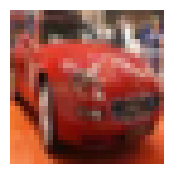

In [5]:
n=5
plt.figure(figsize=(2,2))
plt.axis('off')
plt.imshow(np.transpose(X_train[n], (1,2,0)))
y_label = y_train[n]
print(y_label)
plt.title(f'Label {class_names[y_label]}')
plt.show()

In [ ]:
# 1. Create a single pipeline with a scaler, PCA, and SVM
# The names 'scaler', 'pca', and 'svm' are used to reference the steps in the pipeline.
svm_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('svm', SVC(random_state=42))
])

# 2. Define the parameter grid to search
# 'pca__n_components' refers to the 'n_components' parameter of the 'pca' step.
# 'svm__C' and 'svm__gamma' refer to the parameters of the 'svm' step.
param_grid = {
    'pca__n_components': [100, 200, 300],  # Test different numbers of principal components
    'svm__C': [0.01, 0.1, 1],               # Test different C values for the SVM
    'svm__gamma': ['scale', 'auto']        # Test different gamma values
}

# 3. Initialize and run the Grid Search on the pipeline
# 'cv=3' means 3-fold cross-validation.
grid_search = GridSearchCV(
    estimator=svm_pca_pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # Use all available CPU cores for faster processing
    verbose=2   # Show progress
)

print("Starting Grid Search on the pipeline...")
grid_search.fit(X_train, y_train)

# 4. Get the best parameters and best score
print("\nGrid Search finished.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# The best model is stored in grid_search.best_estimator_
best_model = grid_search.best_estimator_

Starting Grid Search on the pipeline...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


KeyboardInterrupt: 

In [15]:
from sklearn.metrics import accuracy_score
svm_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=300)),  # Use a fixed number of components
    ('svm', SVC(kernel='rbf', C=0.0001, gamma='scale', random_state=42)) # Use fixed hyperparameters
])

print("\nStarting model training...")

# Fit the pipeline to the flattened training data
# This will train a single model, so it will be much faster
svm_pca_pipeline.fit(X_train, y_train)

print("\nModel training finished.")

# Evaluate the model on the unseen test set
print("Evaluating the model on the test set...")
y_pred = svm_pca_pipeline.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
print(f"Final accuracy on test set: {final_accuracy:.4f}")


Starting model training...

Model training finished.
Evaluating the model on the test set...
Final accuracy on test set: 0.3179


In [ ]:
from skimage.feature import hog
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# The shape of your data is (N, C, H, W). HOG expects (N, H, W, C).
# We must transpose the arrays.
X_train_transposed = np.transpose(X_train, (0, 2, 3, 1))
X_test_transposed = np.transpose(X_test, (0, 2, 3, 1))

print("Transposed train shape:", X_train_transposed.shape)
print("Transposed test shape:", X_test_transposed.shape)

# Helper function to extract HOG features from a dataset
def extract_hog_features(images):
    features_list = []
    print("Extracting features...")
    for i, image in enumerate(images):
        if i % 1000 == 0:
            print(f"  Processing image {i}/{len(images)}...")
        
        # Resize image for better HOG feature extraction
        resized_img = resize(image, (64, 64))
        
        # HOG parameters
        hog_features = hog(resized_img, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), transform_sqrt=True, block_norm='L2-Hys',
                           channel_axis=-1)
        features_list.append(hog_features)
    return np.array(features_list)

# We'll use a subset of the data for this example to make training faster
subset_size = 30000
X_train_subset = X_train_transposed[:subset_size]
y_train_subset = y_train[:subset_size]

print("\nExtracting HOG features from the training subset...")
X_train_hog = extract_hog_features(X_train_subset)

print("\nExtracting HOG features from the test set...")
X_test_hog = extract_hog_features(X_test_transposed)

print("\nShape of extracted HOG features:")
print("Training features:", X_train_hog.shape)
print("Test features:", X_test_hog.shape)

# Create a pipeline to scale data and train the SVM
print("\nTraining the SVM classifier...")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

# Fit the model to the HOG features
svm_pipeline.fit(X_train_hog, y_train_subset)

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = svm_pipeline.predict(X_test_hog)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSVM classifier accuracy: {accuracy:.4f}")

Transposed train shape: (50000, 32, 32, 3)
Transposed test shape: (10000, 32, 32, 3)

Extracting HOG features from the training subset...
Extracting features...
  Processing image 0/30000...
  Processing image 1000/30000...
  Processing image 2000/30000...
  Processing image 3000/30000...
  Processing image 4000/30000...
  Processing image 5000/30000...
  Processing image 6000/30000...
  Processing image 7000/30000...
  Processing image 8000/30000...
  Processing image 9000/30000...
  Processing image 10000/30000...
  Processing image 11000/30000...
  Processing image 12000/30000...
  Processing image 13000/30000...
  Processing image 14000/30000...
  Processing image 15000/30000...
  Processing image 16000/30000...
  Processing image 17000/30000...
  Processing image 18000/30000...
  Processing image 19000/30000...
  Processing image 20000/30000...
  Processing image 21000/30000...
  Processing image 22000/30000...
  Processing image 23000/30000...
  Processing image 24000/30000...
  

In [ ]:
50000 ta rasm bor 10 guruhdan bittasi boladi, rasm berilsa qaysi bir guruhga kiradiganini aniqlash